## Cell 1 — Install & Import Libraries

In [1]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Upload & Extract Your Dataset

In [2]:
from google.colab import files

print('Upload your dataset ZIP file...')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f'Uploaded: {zip_name}')


with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset_raw')

print('Extraction complete. Folder structure:')
for root, dirs, files_ in os.walk('/content/dataset_raw'):
    level = root.replace('/content/dataset_raw', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files_[:3]:
            print(f'{indent}  {f}')
        if len(files_) > 3:
            print(f'{indent}  ... ({len(files_)} total files)')

Upload your dataset ZIP file...


Saving archive (1).zip to archive (1).zip
Uploaded: archive (1).zip
Extraction complete. Folder structure:
dataset_raw/
  test/
    dogs/
      dog_563.jpg
      dog_240.jpg
      dog_528.jpg
      ... (70 total files)
    cats/
      cat_5.jpg
      cat_1.jpg
      cat_358.jpg
      ... (70 total files)
  train/
    dogs/
      dog_178.jpg
      dog_299.jpg
      dog_529.jpg
      ... (278 total files)
    cats/
      cat_169.jpg
      cat_123.jpg
      cat_452.jpg
      ... (279 total files)


## Cell 3a — Set Dataset Paths (if already split into train/test)

In [ ]:

TRAIN_DIR = '/content/dataset_raw/train'
TEST_DIR  = '/content/dataset_raw/test'
for split, path in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    cats = len(os.listdir(os.path.join(path, 'cats')))
    dogs = len(os.listdir(os.path.join(path, 'dogs')))
    print(f'{split}: {cats} cats, {dogs} dogs')

Train: 279 cats, 278 dogs
Test: 70 cats, 70 dogs


## Cell 3b — Auto-Split (use this if you have ONE folder of mixed images)

In [ ]:


RAW_DIR   = '/content/dataset_raw'
TRAIN_DIR = '/content/data/train'
TEST_DIR  = '/content/data/test'
SPLIT     = 0.8

for cls in ['cats', 'dogs']:
    os.makedirs(f'{TRAIN_DIR}/{cls}', exist_ok=True)
    os.makedirs(f'{TEST_DIR}/{cls}', exist_ok=True)

def split_and_copy(src_folder, class_name, keyword):
    imgs = [f for f in os.listdir(src_folder)
            if keyword in f.lower() and f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)
    cut = int(len(imgs) * SPLIT)
    for i, f in enumerate(imgs):
        dst = TRAIN_DIR if i < cut else TEST_DIR
        shutil.copy(os.path.join(src_folder, f), f'{dst}/{class_name}/{f}')
    print(f'{class_name}: {cut} train, {len(imgs)-cut} test')

split_and_copy(RAW_DIR, 'cats', 'cat')
split_and_copy(RAW_DIR, 'dogs', 'dog')
print('Split complete!')

cats: 0 train, 0 test
dogs: 0 train, 0 test
Split complete!


## Cell 4 — Configuration

In [ ]:

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32
EPOCHS      = 20
LEARNING_RATE = 0.001
SEED        = 42

CLASS_NAMES = ['cats', 'dogs']
NUM_CLASSES = 2

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Config set:')
print(f'  Image size : {IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Classes    : {CLASS_NAMES}')

Config set:
  Image size : (150, 150)
  Batch size : 32
  Epochs     : 20
  Classes    : ['cats', 'dogs']


## Cell 5 — Data Augmentation & Generators

In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print(f'Class indices: {train_gen.class_indices}')

Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}


## Cell 6 — Visualize Sample Images

Found 557 images belonging to 2 classes.
Re-initialized train_gen with the correct TRAIN_DIR.


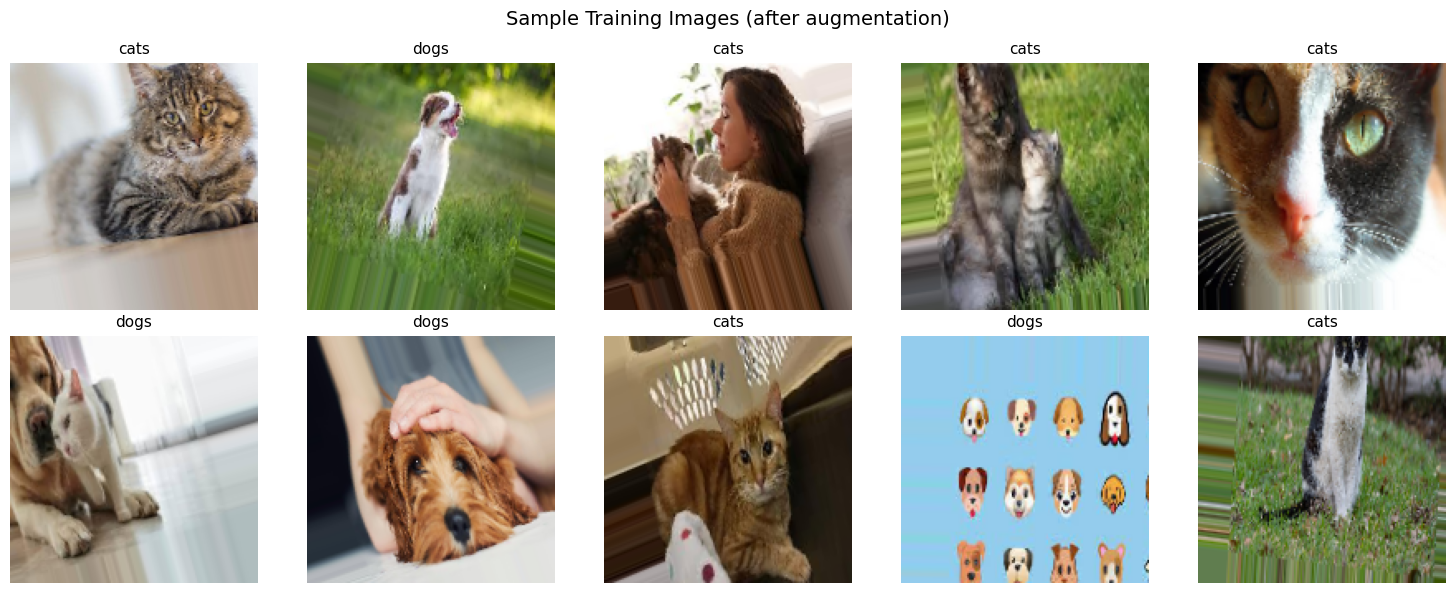

In [ ]:
TRAIN_DIR = '/content/dataset_raw/train'

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    seed=SEED
)
print("Re-initialized train_gen with the correct TRAIN_DIR.")


imgs, labels = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images (after augmentation)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    label_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[label_idx], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Cell 7 — Build the CNN Model

In [ ]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([


        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1_1'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'),
        layers.MaxPooling2D(2, 2, name='pool1'),
        layers.BatchNormalization(),


        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'),
        layers.MaxPooling2D(2, 2, name='pool2'),
        layers.BatchNormalization(),


        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_2'),
        layers.MaxPooling2D(2, 2, name='pool3'),
        layers.BatchNormalization(),


        layers.Flatten(name='flatten'),
        layers.Dense(512, activation='relu', name='fc1'),
        layers.Dropout(0.5, name='dropout1'),
        layers.Dense(256, activation='relu', name='fc2'),
        layers.Dropout(0.3, name='dropout2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = build_cnn((*IMG_SIZE, 3), NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,653,922 (82.60 MB)

 Trainable params: 21,653,474 (82.60 MB)

 Non-trainable params: 448 (1.75 KB)

## Cell 8 — Compile the Model

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


cb_list = [

    callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),

    callbacks.ModelCheckpoint(
        '/content/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print('Model compiled. Ready to train.')

Model compiled. Ready to train.


## Cell 9 — Train the Model

In [ ]:
TEST_DIR = '/content/dataset_raw/test'
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)
print("Re-initialized test_gen with the correct TEST_DIR.")

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=cb_list,
    verbose=1
)

print(f'\nTraining complete. Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')

Found 140 images belonging to 2 classes.
Re-initialized test_gen with the correct TEST_DIR.
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5169 - loss: 5.0439
Epoch 1: val_accuracy improved from None to 0.49286, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 640ms/step - accuracy: 0.5260 - loss: 4.9471 - val_accuracy: 0.4929 - val_loss: 1.5640 - learning_rate: 0.0010
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.5383 - loss: 3.8286
Epoch 2: val_accuracy did not improve from 0.49286
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 402ms/step - accuracy: 0.5422 - loss: 3.9393 - val_accuracy: 0.4643 - val_loss: 0.9373 - learning_rate: 0.0010
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.5385 - loss: 3.7515
Epoch 3: val_accuracy improved from 0.49286 to 0.50000, saving model to /content/best_model.h5



Epoch 3: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 406ms/step - accuracy: 0.5440 - loss: 3.2667 - val_accuracy: 0.5000 - val_loss: 1.9893 - learning_rate: 0.0010
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.5793 - loss: 2.4063
Epoch 4: val_accuracy did not improve from 0.50000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 358ms/step - accuracy: 0.5601 - loss: 2.4847 - val_accuracy: 0.5000 - val_loss: 3.5702 - learning_rate: 0.0010
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5639 - loss: 1.6432
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy improved from 0.50000 to 0.50714, saving model to /content/best_model.h5



Epoch 5: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 426ms/step - accuracy: 0.5224 - loss: 1.5897 - val_accuracy: 0.5071 - val_loss: 1.2838 - learning_rate: 0.0010
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5762 - loss: 1.3878
Epoch 6: val_accuracy did not improve from 0.50714
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 345ms/step - accuracy: 0.5709 - loss: 1.3708 - val_accuracy: 0.5000 - val_loss: 0.7970 - learning_rate: 5.0000e-04
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5604 - loss: 1.1341
Epoch 7: val_accuracy improved from 0.50714 to 0.56429, saving model to /content/best_model.h5



Epoch 7: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 425ms/step - accuracy: 0.5583 - loss: 1.1148 - val_accuracy: 0.5643 - val_loss: 0.7346 - learning_rate: 5.0000e-04
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5620 - loss: 1.1833
Epoch 8: val_accuracy did not improve from 0.56429
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 389ms/step - accuracy: 0.5530 - loss: 1.1146 - val_accuracy: 0.5214 - val_loss: 0.7534 - learning_rate: 5.0000e-04
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5874 - loss: 0.9418
Epoch 9: val_accuracy did not improve from 0.56429
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 347ms/step - accuracy: 0.5943 - loss: 0.9793 - val_accuracy: 0.5500 - val_loss: 0.7475 - learning_rate: 5.0000e-04
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.5985 - loss: 0.9452
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_accuracy did not improve from 0.56429
18/18 ━━━━━━━━━━

## Cell 10 — Plot Training Curves

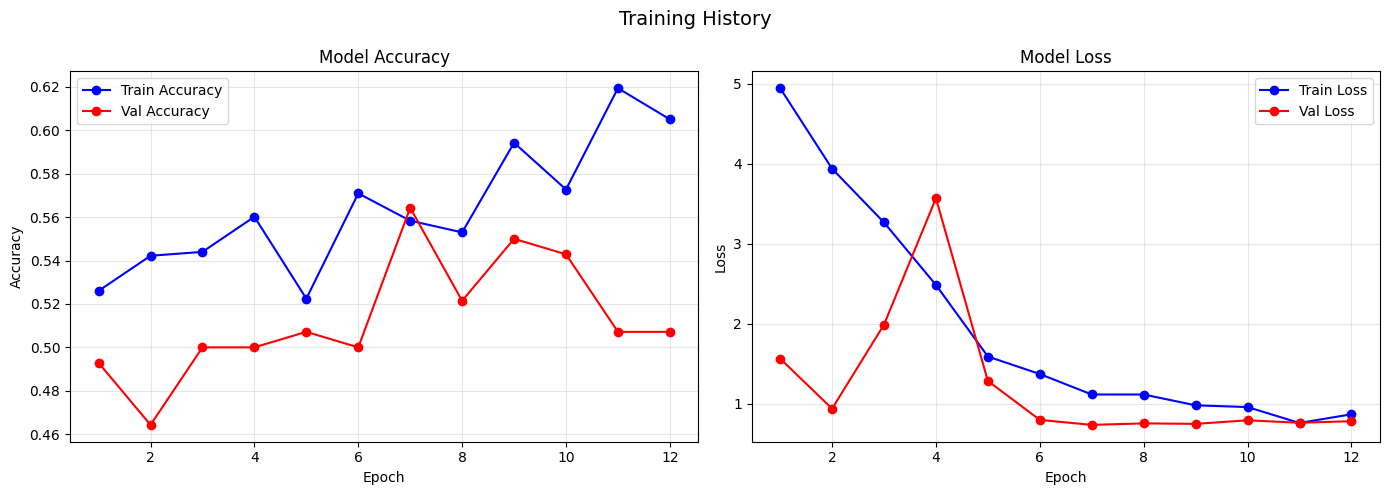

Saved to /content/training_curves.png


In [ ]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs_ran = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, acc,     'b-o', label='Train Accuracy')
ax1.plot(epochs_ran, val_acc, 'r-o', label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, loss,     'b-o', label='Train Loss')
ax2.plot(epochs_ran, val_loss, 'r-o', label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/training_curves.png')

## Cell 11 — Evaluate on Test Set

In [ ]:
test_gen.reset()
loss, accuracy = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {loss:.4f}')
print(f'Test Accuracy : {accuracy*100:.2f}%')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5643 - loss: 0.7346

Test Loss     : 0.7346
Test Accuracy : 56.43%


## Cell 12 — Confusion Matrix & Classification Report

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step

Classification Report:
              precision    recall  f1-score   support

        cats       0.60      0.37      0.46        70
        dogs       0.55      0.76      0.63        70

    accuracy                           0.56       140
   macro avg       0.58      0.56      0.55       140
weighted avg       0.58      0.56      0.55       140



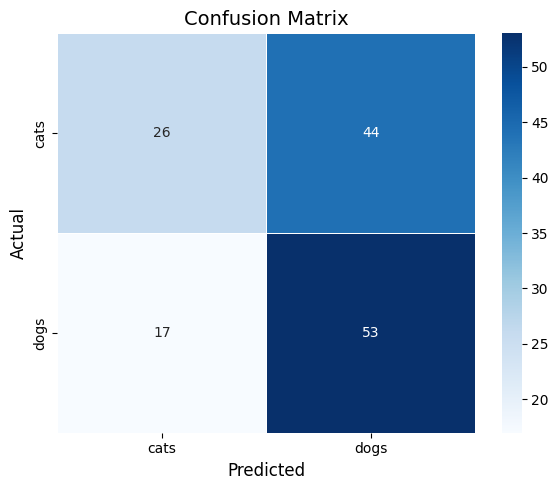

Saved to /content/confusion_matrix.png


In [ ]:
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/confusion_matrix.png')

## Cell 13 — Visualize Predictions on Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step


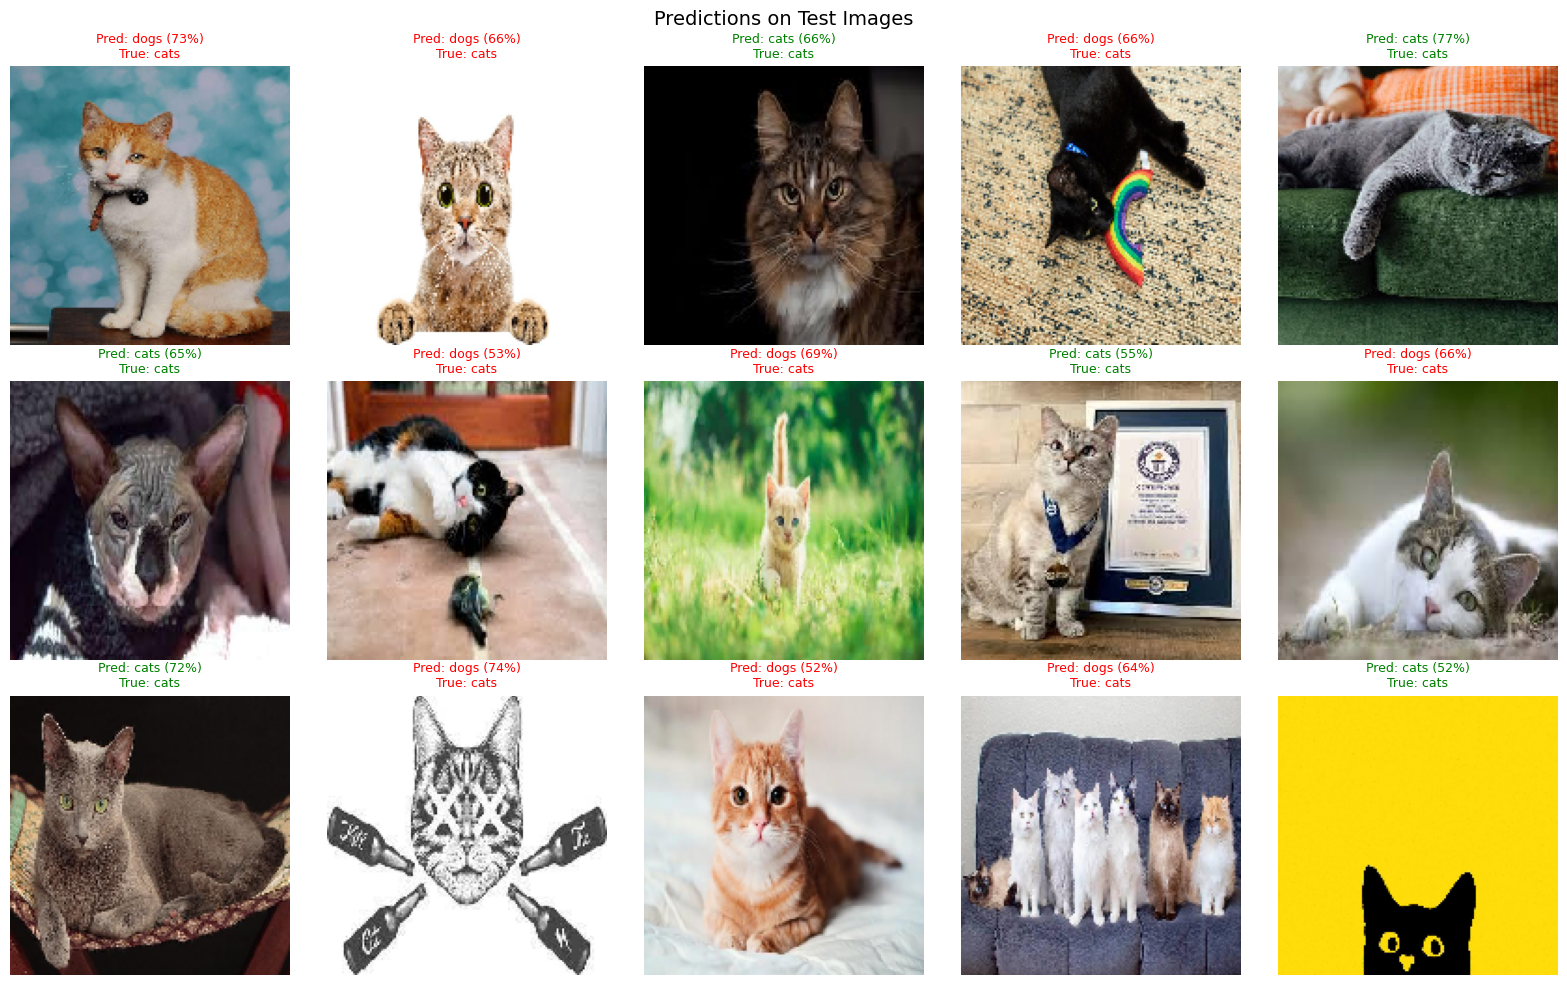

Saved to /content/predictions.png


In [ ]:
test_gen.reset()
sample_imgs, sample_labels = next(test_gen)
preds = model.predict(sample_imgs)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle('Predictions on Test Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs):
        ax.axis('off')
        continue
    ax.imshow(sample_imgs[i])
    true_label = CLASS_NAMES[np.argmax(sample_labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    conf = np.max(preds[i]) * 100
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'Pred: {pred_label} ({conf:.0f}%)\nTrue: {true_label}',
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/predictions.png')

## Cell 14 — Predict on a Single New Image

Upload a single cat or dog image to test:


Saving dog_68.jpg to dog_68.jpg


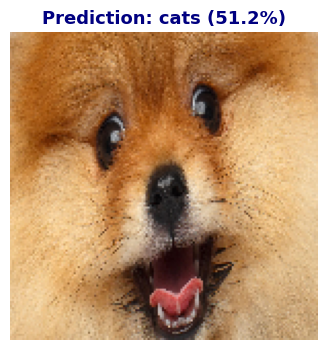

  Cat: 51.2%
  Dog: 48.8%


('cats', np.float32(51.204205))

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np # Required for np.expand_dims and np.argmax
import matplotlib.pyplot as plt # Required for plt.figure, plt.imshow, etc.
import tensorflow as tf # Required for tf.keras.models.load_model

# Define configuration variables needed by this cell
IMG_SIZE = (150, 150)
CLASS_NAMES = ['cats', 'dogs']

def predict_image(img_path, model, class_names, img_size=(150,150)):
    img = keras_image.load_img(img_path, target_size=img_size)
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    pred_idx = np.argmax(probs)
    label = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(keras_image.load_img(img_path, target_size=img_size))
    plt.title(f'Prediction: {label} ({confidence:.1f}%)', fontsize=13,
              color='navy', fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f'  Cat: {probs[0]*100:.1f}%')
    print(f'  Dog: {probs[1]*100:.1f}%')
    return label, confidence

# ── Upload a single image to test ────────────────────────────
from google.colab import files as colab_files
print('Upload a single cat or dog image to test:')
uploaded_img = colab_files.upload()
img_path = list(uploaded_img.keys())[0]

# Load the best model saved during training to ensure it's defined
model = tf.keras.models.load_model('/content/best_model.h5')

predict_image(img_path, model, CLASS_NAMES, IMG_SIZE)

## Cell 15 — Save & Download the Model

In [ ]:

model.save('/content/cat_dog_cnn_final.h5')
print('Model saved to /content/cat_dog_cnn_final.h5')


model.export('/content/cat_dog_cnn_savedmodel')
print('SavedModel saved to /content/cat_dog_cnn_savedmodel/')


from google.colab import files as colab_files
colab_files.download('/content/cat_dog_cnn_final.h5')
print('Download started!')

Model saved to /content/cat_dog_cnn_final.h5
Saved artifact at '/content/cat_dog_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133604289818320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289818896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289820432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289819664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289820240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289821200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289819088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289820816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289819280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133604289818512: TensorSp

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import callbacks
import os


TRAIN_DIR = '/content/dataset_raw/train'
TEST_DIR  = '/content/dataset_raw/test'
IMG_SIZE  = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 2


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)


cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('/content/best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1) # Fixed: Added closing parenthesis and missing arguments
]


Found 557 images belonging to 2 classes.
Found 140 images belonging to 2 classes.


## Cell 16 — (Optional) Transfer Learning with MobileNetV2

In [ ]:


from tensorflow import keras
from tensorflow.keras import models, layers


IMG_SIZE = (150, 150)
NUM_CLASSES = 2

base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()


print('Training classifier head...')
transfer_model.fit(
    train_gen, epochs=10,
    validation_data=test_gen,
    callbacks=cb_list
)


base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Fine-tuning top layers...')
transfer_model.fit(
    train_gen, epochs=10,
    validation_data=test_gen,
    callbacks=cb_list
)

loss, acc = transfer_model.evaluate(test_gen)
print(f'\nTransfer Learning Test Accuracy: {acc*100:.2f}%')

/tmp/ipykernel_12169/3556947389.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,434 (9.87 MB)

 Trainable params: 328,450 (1.25 MB)

...


Epoch 1: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.7720 - loss: 0.5479 - val_accuracy: 0.8429 - val_loss: 0.5023 - learning_rate: 0.0010
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8875 - loss: 0.3379
Epoch 2: val_accuracy improved from 0.84286 to 0.87857, saving model to /content/best_model.h5



Epoch 2: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step - accuracy: 0.8923 - loss: 0.3083 - val_accuracy: 0.8786 - val_loss: 0.3781 - learning_rate: 0.0010
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9011 - loss: 0.2504
Epoch 3: val_accuracy did not improve from 0.87857
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 332ms/step - accuracy: 0.9102 - loss: 0.2330 - val_accuracy: 0.8643 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9313 - loss: 0.1886
Epoch 4: val_accuracy improved from 0.87857 to 0.92857, saving model to /content/best_model.h5



Epoch 4: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 398ms/step - accuracy: 0.9300 - loss: 0.1733 - val_accuracy: 0.9286 - val_loss: 0.1994 - learning_rate: 0.0010
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9328 - loss: 0.1839
Epoch 5: val_accuracy did not improve from 0.92857
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 334ms/step - accuracy: 0.9354 - loss: 0.1701 - val_accuracy: 0.9286 - val_loss: 0.1728 - learning_rate: 0.0010
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9306 - loss: 0.1596
Epoch 6: val_accuracy did not improve from 0.92857
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step - accuracy: 0.9300 - loss: 0.1616 - val_accuracy: 0.8714 - val_loss: 0.2845 - learning_rate: 0.0010
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9325 - loss: 0.1425
Epoch 7: val_accuracy did not improve from 0.92857
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 330ms/step - accuracy: 0.9372 - loss: 0.1448 - val_accuracy: 0.9071 - val_loss


Epoch 4: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 368ms/step - accuracy: 0.8959 - loss: 0.2302 - val_accuracy: 0.9357 - val_loss: 0.1583 - learning_rate: 1.0000e-05
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9209 - loss: 0.1956
Epoch 5: val_accuracy improved from 0.93571 to 0.95000, saving model to /content/best_model.h5



Epoch 5: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.9210 - loss: 0.2035 - val_accuracy: 0.9500 - val_loss: 0.1555 - learning_rate: 1.0000e-05
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9136 - loss: 0.2193
Epoch 6: val_accuracy did not improve from 0.95000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 384ms/step - accuracy: 0.9174 - loss: 0.2050 - val_accuracy: 0.9500 - val_loss: 0.1524 - learning_rate: 1.0000e-05
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9170 - loss: 0.2139
Epoch 7: val_accuracy did not improve from 0.95000
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 333ms/step - accuracy: 0.9174 - loss: 0.2032 - val_accuracy: 0.9357 - val_loss: 0.1518 - learning_rate: 1.0000e-05
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9278 - loss: 0.1900
Epoch 8: val_accuracy did not improve from 0.95000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 383ms/step - accuracy: 0.9138 - loss: 0.2048 - val_accuracy: 0.928